In [1]:
import numpy as np
import pandas as pd
import anndata as ad
import decoupler as dc
import matplotlib.pyplot as plt
import seaborn as sns
import math
import scanpy as sc
import mudata as md
import mofaflex as mf
import os
import mina

/home/loan/Documents/Tests/MINA/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Importing the dtw module. When using in academic works please cite:
  T. Giorgino. Computing and Visualizing Dynamic Time Warping Alignments in R: The dtw Package.
  J. Stat. Soft., doi:10.18637/jss.v031.i07.



... storing 'biosample_id' as categorical


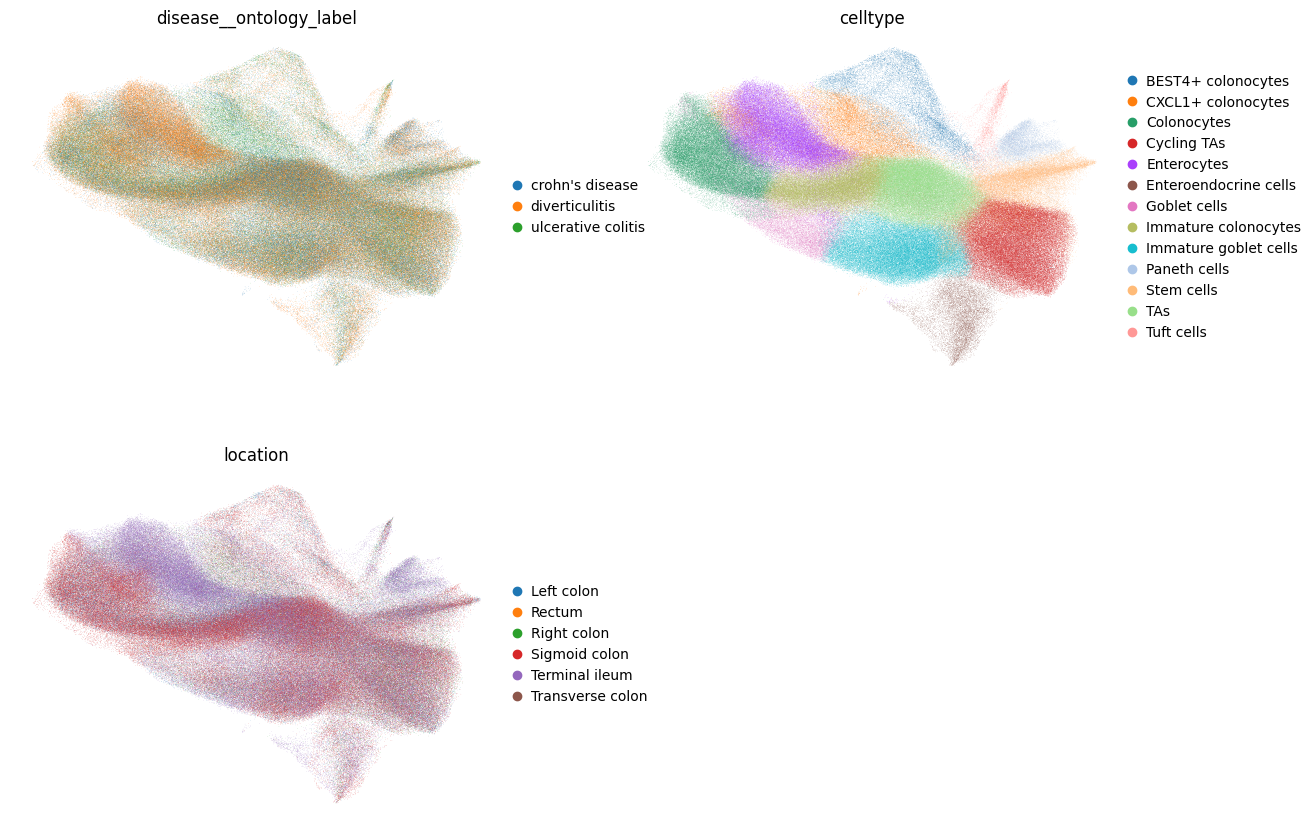

In [2]:
adata = ad.read_h5ad("./data/scp_xenium_human_epi.h5ad")
adata.obs["biosample_id"] = adata.obs["biosample_id"].astype("str")
sc.pl.umap(adata, color=["disease__ontology_label", 'celltype', 'location'], frameon=False, ncols=2)

In [3]:
# We extract the metadata based on our column that is the reference
# Filter adata to only include ileum
# Process adata_raw
metadata = mina.up.extract_metadata_from_obs(obs=adata.obs, groupby="biosample_id", sort=False)
pdata = dc.pp.pseudobulk(adata, sample_col="biosample_id", groups_col="celltype", layer="counts")

# Manipulations on pdata
pdata.obs = pdata.obs.set_index("biosample_id", drop=False)
pdata.obs.index.name = None

# Make list of adatas per pseudobulk cell type
anndata_dict = mina.up.split_anndata_by_celltype(pdata=pdata, grouping="celltype")

# Adding gene expression total counts - TODO add to upstream as a function
for _cell_type, adata_raw in anndata_dict.items():
    # Sum across observations (rows) for each gene (column)
    if hasattr(adata_raw.X, "toarray"):
        # Sparse matrix case
        total_counts = adata_raw.X.sum(axis=0).A1  # returns 1D array
    else:
        total_counts = adata_raw.X.sum(axis=0)  # numpy array

    # Add to .var
    adata_raw.var["total_counts"] = total_counts


# From all the possible samples, let's ask for at least 40%
n_samples = len(metadata.index)
min_samples = math.trunc(n_samples * 0.4)

# Do filters
mina.up.filter_anndata_by_ncells(anndata_dict, min_cells=20)
mina.up.filter_views_by_samples(anndata_dict, min_rows=min_samples)
mina.up.filter_genes_byexpr(anndata_dict, min_count=20, min_prop=0.4)
mina.up.filter_views_by_genes(anndata_dict, min_genes_per_view=100)
mina.up.filter_samples_by_coverage(anndata_dict, threshold=0, min_prop=0.90)
mina.up.filter_views_by_samples(anndata_dict, min_rows=min_samples)
mina.up.save_raw_counts(anndata_dict, layer_name="raw_counts")
mina.up.norm_log(anndata_dict, target_sum=1e6, exclude_highly_expressed=False, max_value=None, center=True)
mina.up.filter_hvgs(anndata_dict, groupby = None, ngroups_cut = None)
mina.up.filter_smpls_by_nview(anndata_dict, min_views = 5)
mina.up.utils.append_view_to_var(anndata_dict)

/home/loan/Documents/Tests/MINA/.venv/lib/python3.13/site-packages/anndata/_core/anndata.py:770: UserWarning: 
AnnData expects .obs.index to contain strings, but got values like:
    ['107990', '108731', '117237', '144732', '146685']

    Inferred to be: categorical



Raw counts saved in the 'raw_counts' layer for each AnnData object.
Normalization, log-transformation, and scaling complete for all AnnData objects with target_sum = 1000000.0.


/home/loan/Documents/Tests/MINA/.venv/lib/python3.13/site-packages/mudata/_core/mudata.py:1403: FutureWarning: From 0.4 .update() will not pull obs/var columns from individual modalities by default anymore. Set mudata.set_options(pull_on_update=False) to adopt the new behaviour, which will become the default. Use new pull_obs/pull_var and push_obs/push_var methods for more flexibility.
/home/loan/Documents/Tests/MINA/.venv/lib/python3.13/site-packages/mudata/_core/mudata.py:1275: FutureWarning: From 0.4 .update() will not pull obs/var columns from individual modalities by default anymore. Set mudata.set_options(pull_on_update=False) to adopt the new behaviour, which will become the default. Use new pull_obs/pull_var and push_obs/push_var methods for more flexibility.
/home/loan/Documents/Tests/MINA/.venv/lib/python3.13/site-packages/mudata/_core/mudata.py:1403: FutureWarning: From 0.4 .update() will not pull obs/var columns from individual modalities by default anymore. Set mudata.set_

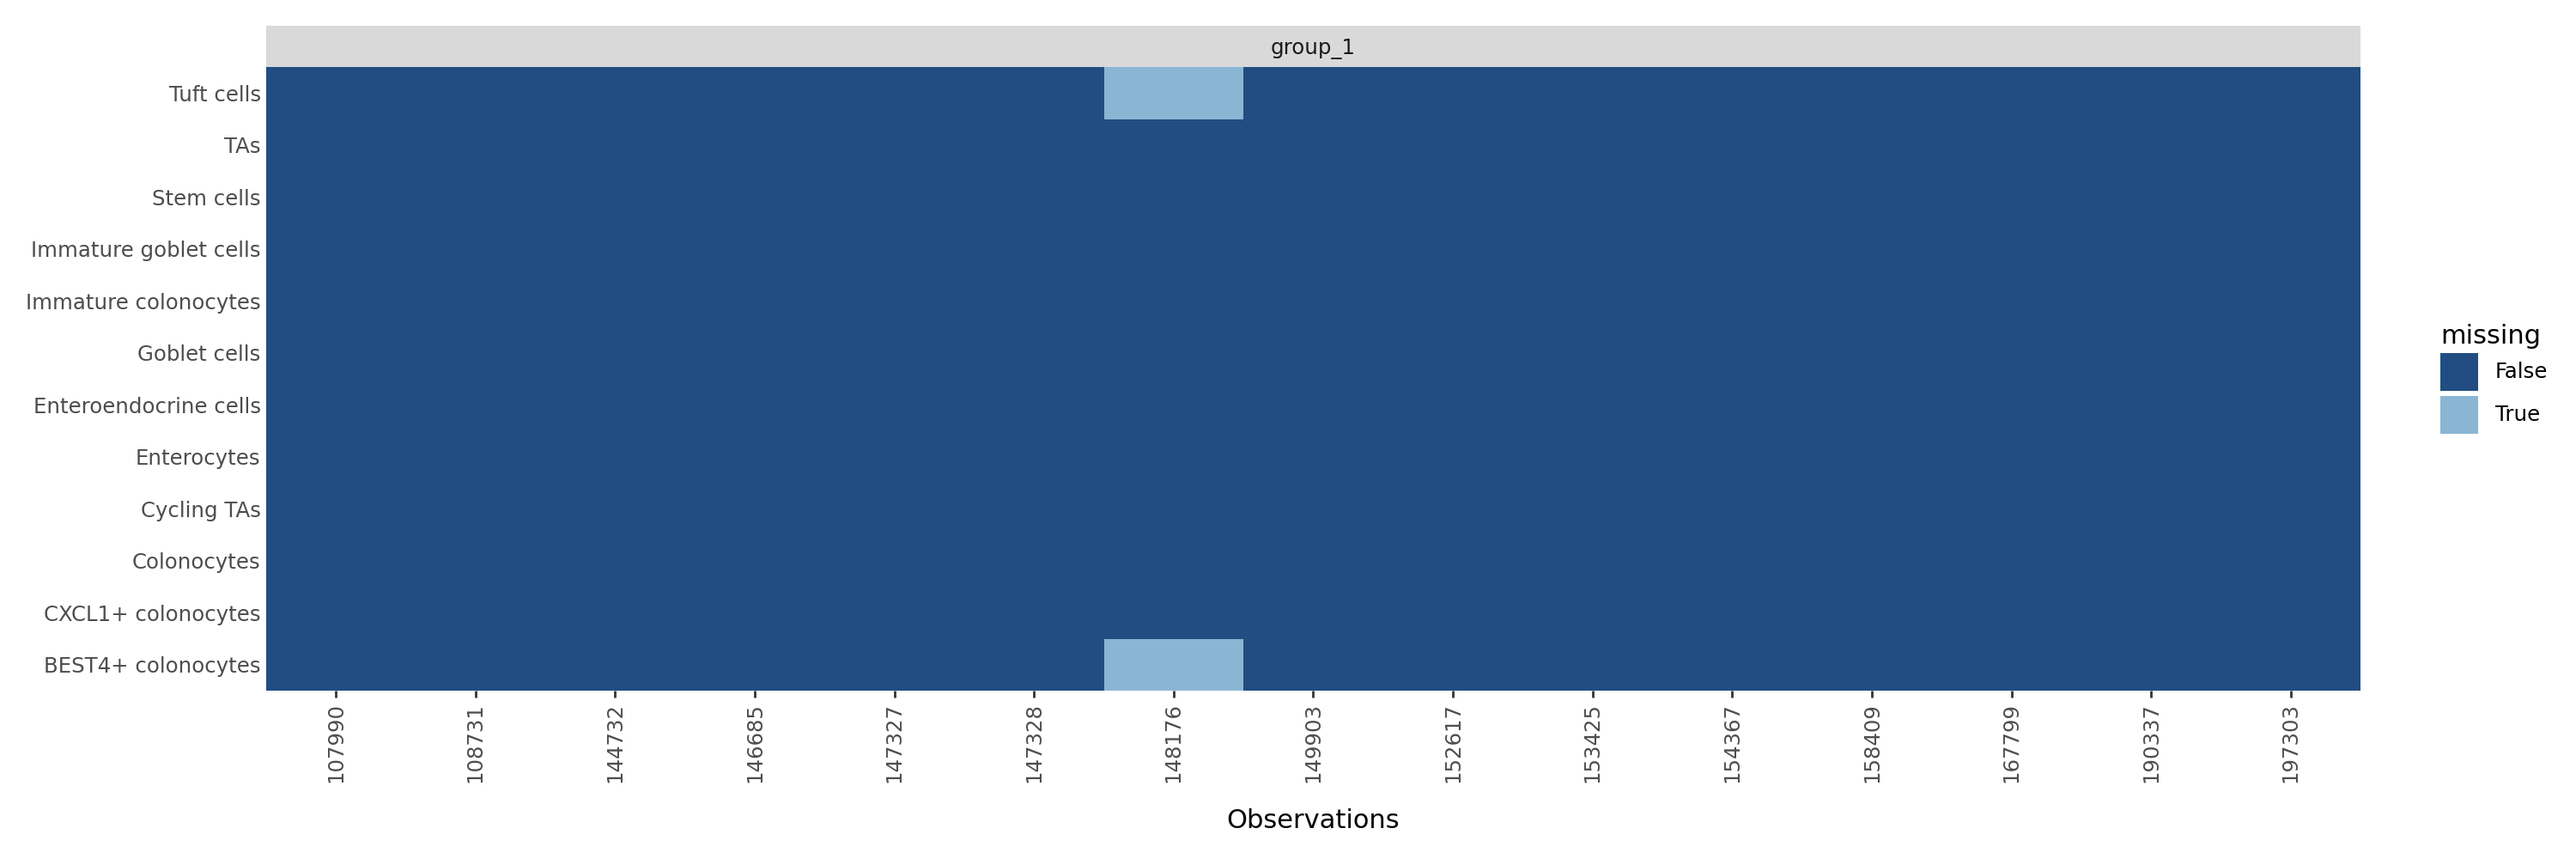

/home/loan/Documents/Tests/MINA/.venv/lib/python3.13/site-packages/mudata/_core/mudata.py:1403: FutureWarning: From 0.4 .update() will not pull obs/var columns from individual modalities by default anymore. Set mudata.set_options(pull_on_update=False) to adopt the new behaviour, which will become the default. Use new pull_obs/pull_var and push_obs/push_var methods for more flexibility.
/home/loan/Documents/Tests/MINA/.venv/lib/python3.13/site-packages/mudata/_core/mudata.py:1275: FutureWarning: From 0.4 .update() will not pull obs/var columns from individual modalities by default anymore. Set mudata.set_options(pull_on_update=False) to adopt the new behaviour, which will become the default. Use new pull_obs/pull_var and push_obs/push_var methods for more flexibility.
/home/loan/Documents/Tests/MINA/.venv/lib/python3.13/site-packages/mudata/_core/mudata.py:1403: FutureWarning: From 0.4 .update() will not pull obs/var columns from individual modalities by default anymore. Set mudata.set_

In [4]:
mdata = md.MuData(anndata_dict)
# Fitting model
model = mf.terms.MofaFlex(n_factors=3, weight_prior="SpikeSlab", init_factors="pca")
model.fit(mdata, seed=42, save_path=False, lr=0.01, early_stopper_patience=1000, likelihoods="Normal")

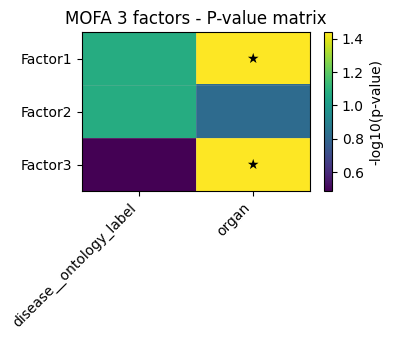

In [5]:
amodel = mina.down.model_to_anndata(
    anndata_dict=anndata_dict,
    metadata=metadata,
    model=model,
)

# Get the p-value matrix for the associations of interest (adjusted)
all_assocs = mina.down.get_pval_matrix(amodel,["disease__ontology_label", "organ"])
mina.pl.pl.plot_pval_tiles(all_assocs, title="MOFA 3 factors - P-value matrix",star_threshold=0.05)
plt.show()

In [6]:
spatial_interaction_adata = mina.up.get_nhood_enrichment_feats(
    adata,
    sample_key="biosample_id",
    cluster_key="celltype",
    diagonal = True, # To co
    n_perms=1000,
)

# Don't forget to add the view name to the variables for compatibility
mina.up.utils.append_view_to_var({"Spatial":spatial_interaction_adata})

anndata_dict["Spatial"] = spatial_interaction_adata

INFO     Creating graph using `generic` coordinates and `None` transform and `1` libraries.                        


100%|██████████| 1000/1000 [00:00<00:00, 4639.20/s]


INFO     Creating graph using `generic` coordinates and `None` transform and `1` libraries.                        


100%|██████████| 1000/1000 [00:00<00:00, 1274.03/s]


INFO     Creating graph using `generic` coordinates and `None` transform and `1` libraries.                        


...

100%|██████████| 1000/1000 [00:00<00:00, 1384.03/s]

INFO     Creating graph using `generic` coordinates and `None` transform and `1` libraries.                        



100%|██████████| 1000/1000 [00:00<00:00, 10944.13/s]
/home/loan/Documents/Tests/MINA/.venv/lib/python3.13/site-packages/squidpy/gr/_nhood.py:217: RuntimeWarning: invalid value encountered in divide


INFO     Creating graph using `generic` coordinates and `None` transform and `1` libraries.                        


100%|██████████| 1000/1000 [00:01<00:00, 703.10/s]


/home/loan/Documents/Tests/MINA/.venv/lib/python3.13/site-packages/mudata/_core/mudata.py:1403: FutureWarning: From 0.4 .update() will not pull obs/var columns from individual modalities by default anymore. Set mudata.set_options(pull_on_update=False) to adopt the new behaviour, which will become the default. Use new pull_obs/pull_var and push_obs/push_var methods for more flexibility.
/home/loan/Documents/Tests/MINA/.venv/lib/python3.13/site-packages/mudata/_core/mudata.py:1275: FutureWarning: From 0.4 .update() will not pull obs/var columns from individual modalities by default anymore. Set mudata.set_options(pull_on_update=False) to adopt the new behaviour, which will become the default. Use new pull_obs/pull_var and push_obs/push_var methods for more flexibility.
/home/loan/Documents/Tests/MINA/.venv/lib/python3.13/site-packages/mudata/_core/mudata.py:1403: FutureWarning: From 0.4 .update() will not pull obs/var columns from individual modalities by default anymore. Set mudata.set_

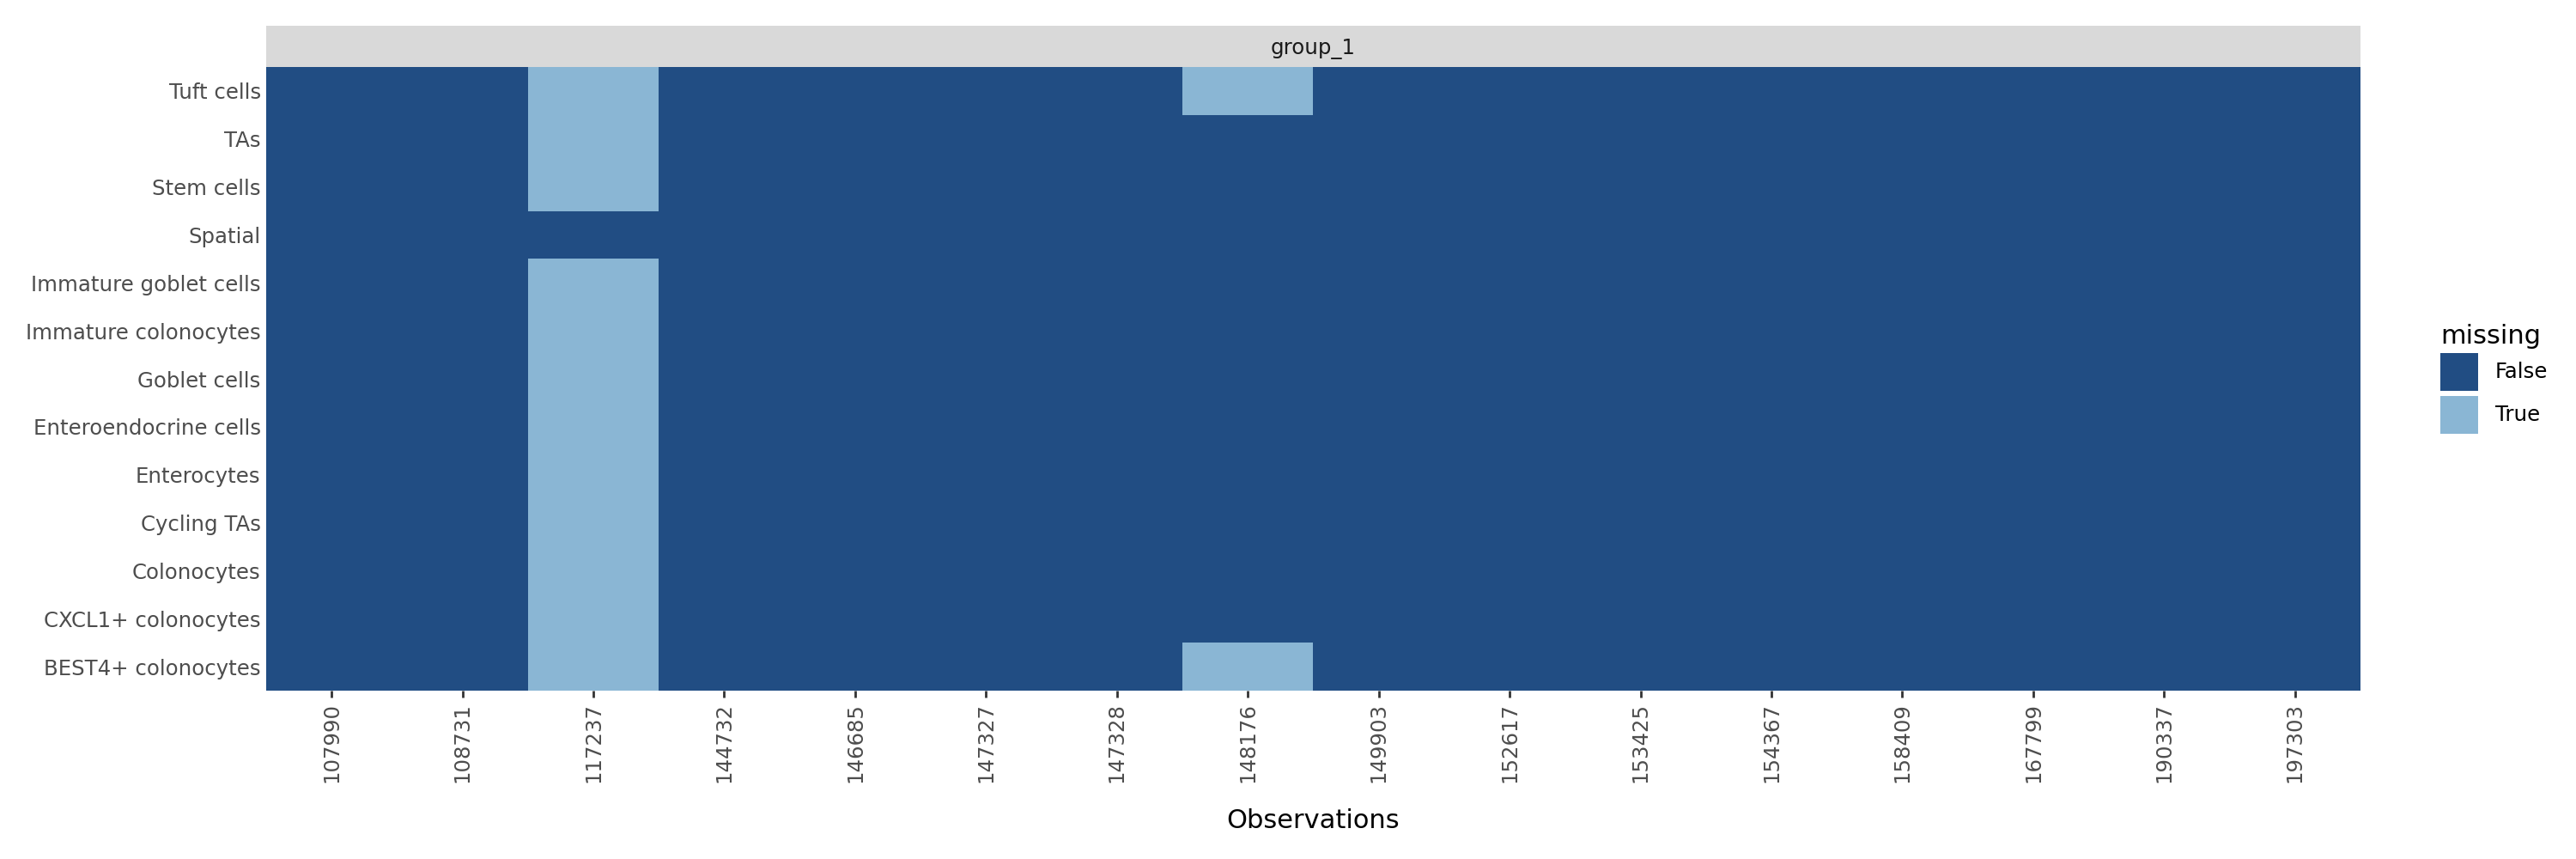

/home/loan/Documents/Tests/MINA/.venv/lib/python3.13/site-packages/mudata/_core/mudata.py:1403: FutureWarning: From 0.4 .update() will not pull obs/var columns from individual modalities by default anymore. Set mudata.set_options(pull_on_update=False) to adopt the new behaviour, which will become the default. Use new pull_obs/pull_var and push_obs/push_var methods for more flexibility.
/home/loan/Documents/Tests/MINA/.venv/lib/python3.13/site-packages/mudata/_core/mudata.py:1275: FutureWarning: From 0.4 .update() will not pull obs/var columns from individual modalities by default anymore. Set mudata.set_options(pull_on_update=False) to adopt the new behaviour, which will become the default. Use new pull_obs/pull_var and push_obs/push_var methods for more flexibility.
/home/loan/Documents/Tests/MINA/.venv/lib/python3.13/site-packages/mudata/_core/mudata.py:1403: FutureWarning: From 0.4 .update() will not pull obs/var columns from individual modalities by default anymore. Set mudata.set_

In [7]:
mdata = md.MuData(anndata_dict)
# Fitting model
model_spatial = mf.terms.MofaFlex(n_factors=3, weight_prior="SpikeSlab", init_factors="pca")
model_spatial.fit(mdata, seed=42, save_path=False, lr=0.01, early_stopper_patience=1000, likelihoods="Normal")

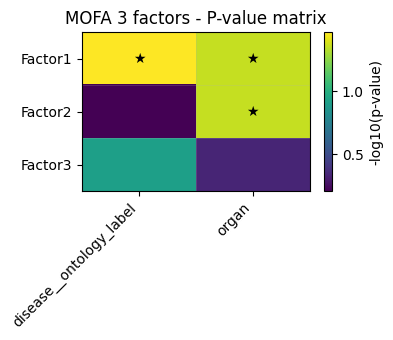

In [8]:
amodel = mina.down.model_to_anndata(
    anndata_dict=anndata_dict,
    metadata=metadata,
    model=model_spatial,
)

# Get the p-value matrix for the associations of interest (adjusted)
all_assocs = mina.down.get_pval_matrix(amodel,["disease__ontology_label", "organ"])
mina.pl.pl.plot_pval_tiles(all_assocs, title="MOFA 3 factors - P-value matrix",star_threshold=0.05)
plt.show()

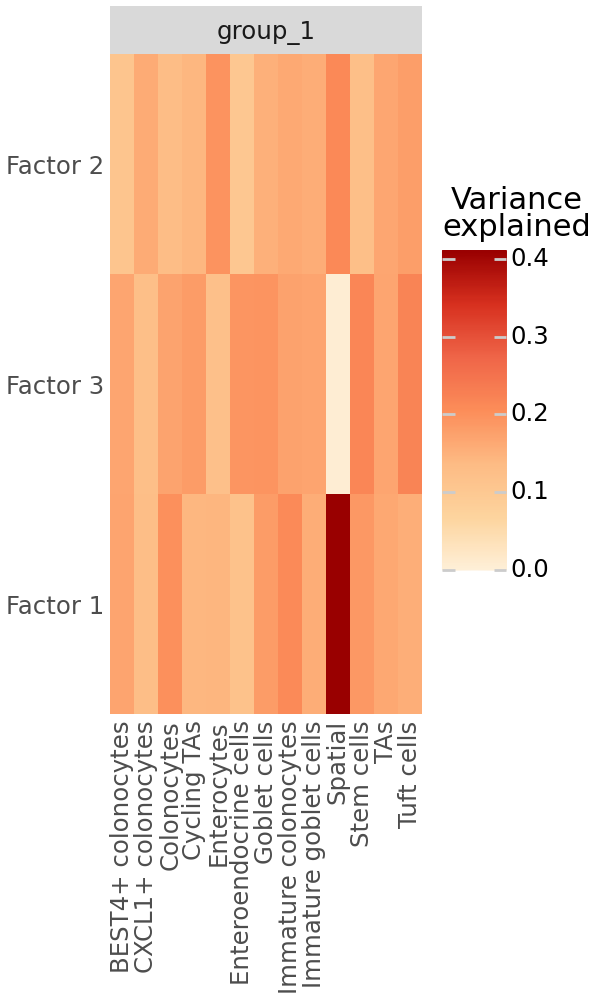

In [9]:
mf.pl.variance_explained(model_spatial)

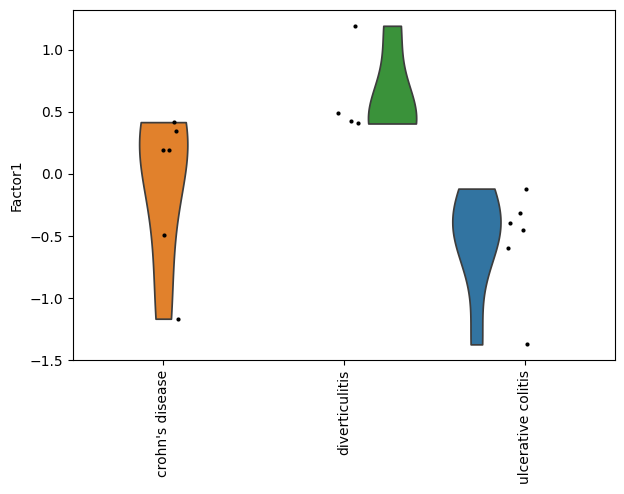

In [10]:
sc.pl.violin(amodel, 
             "Factor1", 
             groupby="disease__ontology_label", rotation=90,size = 3)

In [11]:
feature_loadings = pd.DataFrame(amodel.varm["gene_loadings"], columns=amodel.uns['gene_loadings_columns'])
feature_loadings.index = amodel.var.index.to_list()

# Make a dictionary of gene expression data
feature_loadings = mina.down.split_by_view(feature_loadings)

In [12]:
# Take the top loadings for the spatial view
spatial_loadings = {"Spatial":feature_loadings["Spatial"]}
feature_loadings = {k:v for k,v in feature_loadings.items() if k != "Spatial"}

In [13]:
# Pick top 10 most negative and positive loadings for the spatial view
F1_loadings = spatial_loadings["Spatial"].loc["Factor1",:]
F1_loadings = F1_loadings.sort_values()
top_pos = F1_loadings.tail(10)
top_neg = F1_loadings.head(10)
top_loadings = pd.concat([top_pos, top_neg])

/home/loan/Documents/Tests/MINA/src/mina/pl/pl.py:755: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.


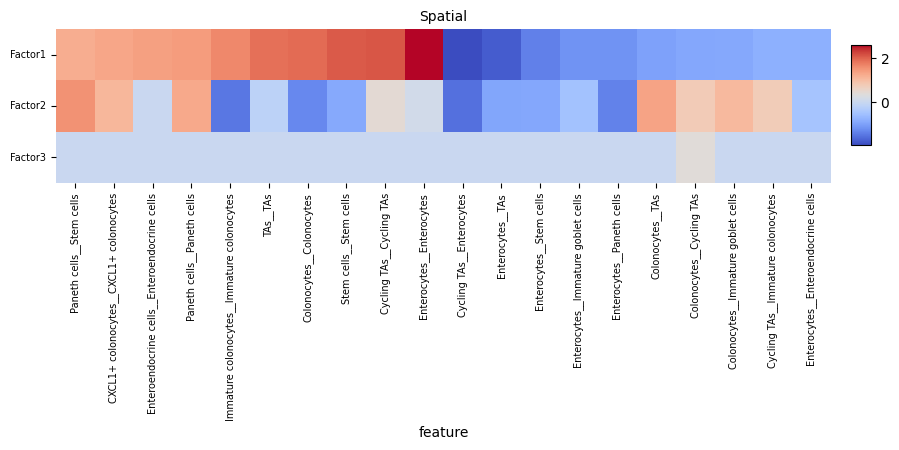

In [14]:
mina.pl.plot_features_per_view(df_dict=spatial_loadings, features=top_loadings.index.tolist(), figsize=(10, 2))

In [15]:
# Get the samples with the highest and lowest factor values for factor 1, data in X
factor_values = amodel.X[:, 0]  # Factor 1 values
top_samples = np.argsort(factor_values)[-2:]  # Top 1 samples
bottom_samples = np.argsort(factor_values)[:2]  # Bottom 1 samples
# put them in a list
top_bottom_samples = np.concatenate([top_samples, bottom_samples])
top_bottom_samples = amodel.obs.iloc[top_bottom_samples]
top_bottom_samples = top_bottom_samples["biosample_id"].tolist()

/home/loan/Documents/Tests/MINA/.venv/lib/python3.13/site-packages/squidpy/pl/_spatial_utils.py:982: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap', 'norm' will be ignored
/home/loan/Documents/Tests/MINA/.venv/lib/python3.13/site-packages/squidpy/pl/_spatial_utils.py:982: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap', 'norm' will be ignored
/home/loan/Documents/Tests/MINA/.venv/lib/python3.13/site-packages/squidpy/pl/_spatial_utils.py:982: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap', 'norm' will be ignored
/home/loan/Documents/Tests/MINA/.venv/lib/python3.13/site-packages/squidpy/pl/_spatial_utils.py:982: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap', 'norm' will be ignored


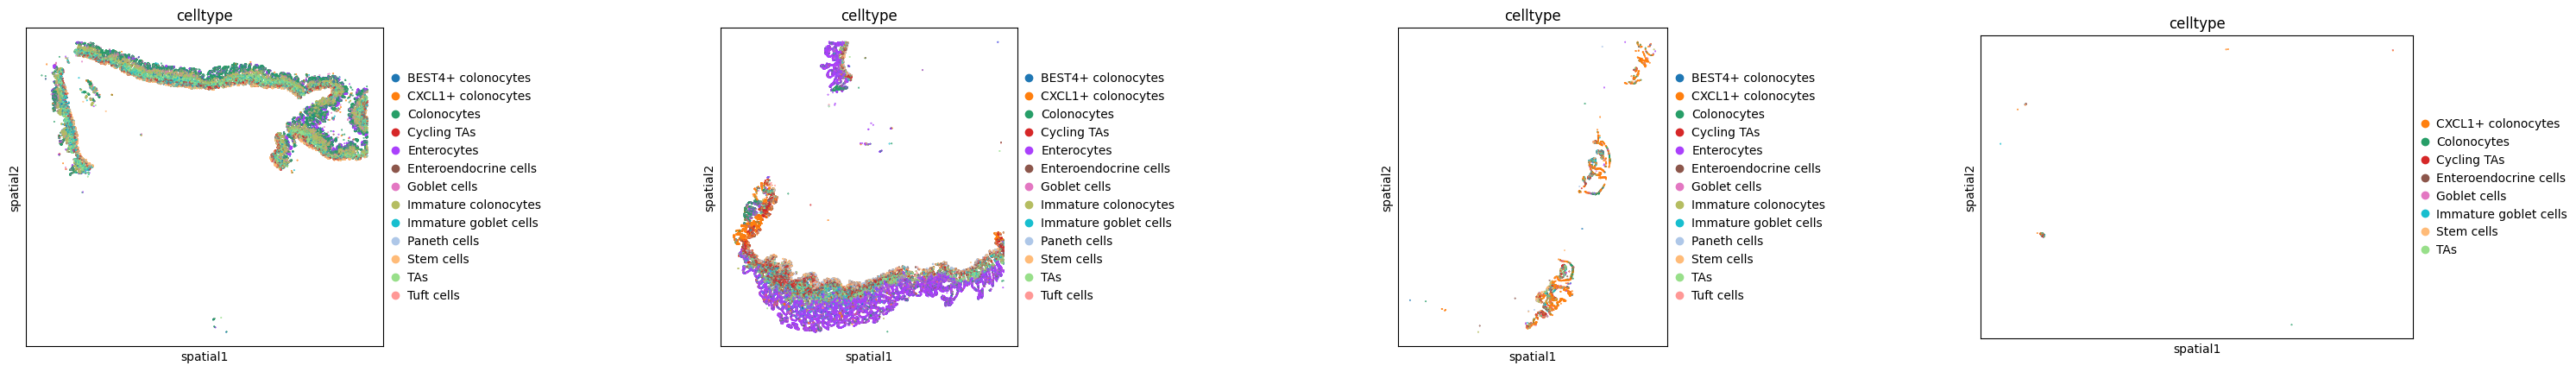

In [16]:
import squidpy as sq

sq.pl.spatial_scatter(
    adata,
    library_key= "biosample_id",
    library_id = top_bottom_samples,
    shape=None,
    color=[
        "celltype",
    ],
    wspace=0.4,
)

In [17]:
MINs = mina.down.get_multicell_net(
    test_model = amodel,
    sel_factor = "Factor1",
    random_effect = None,
    standardize = True,
    drop_na = True,
    verbose = True,
    views=[k for k in feature_loadings.keys()],
    percentile=0.6
)

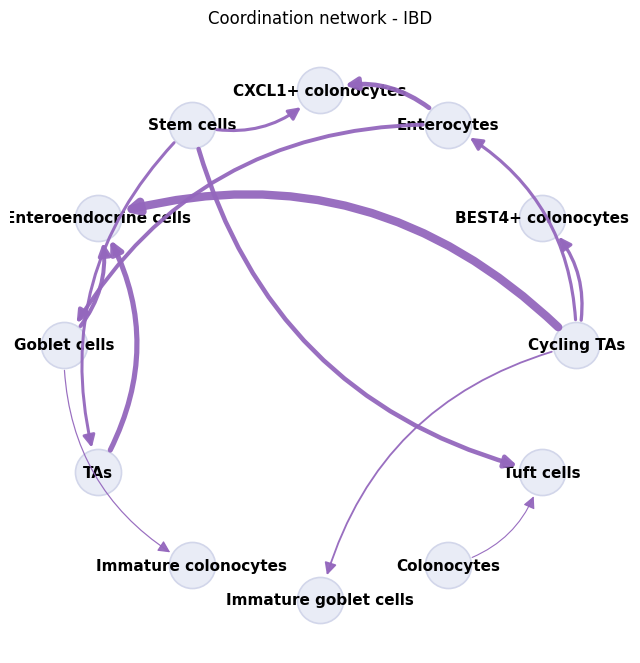

In [18]:
graph_viz = mina.pl.plot_mcell_network(
    df = MINs["negative"],
    weight_col="cor_estimate",
    abs_cutoff=0.8,
    keep_negative=False,
    title="Coordination network - IBD",
    show_edge_labels = False,
    save_path=None,
    reciprocal_curvature=0.3,
    default_curvature=0.4)

Running ULM for view: BEST4+ colonocytes
Running ULM for view: CXCL1+ colonocytes
Running ULM for view: Colonocytes
Running ULM for view: Cycling TAs
Running ULM for view: Enterocytes
Running ULM for view: Enteroendocrine cells
Running ULM for view: Goblet cells
Running ULM for view: Immature colonocytes
Running ULM for view: Immature goblet cells
Running ULM for view: Stem cells
Running ULM for view: TAs
Running ULM for view: Tuft cells


/home/loan/Documents/Tests/MINA/src/mina/pl/pl.py:474: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.


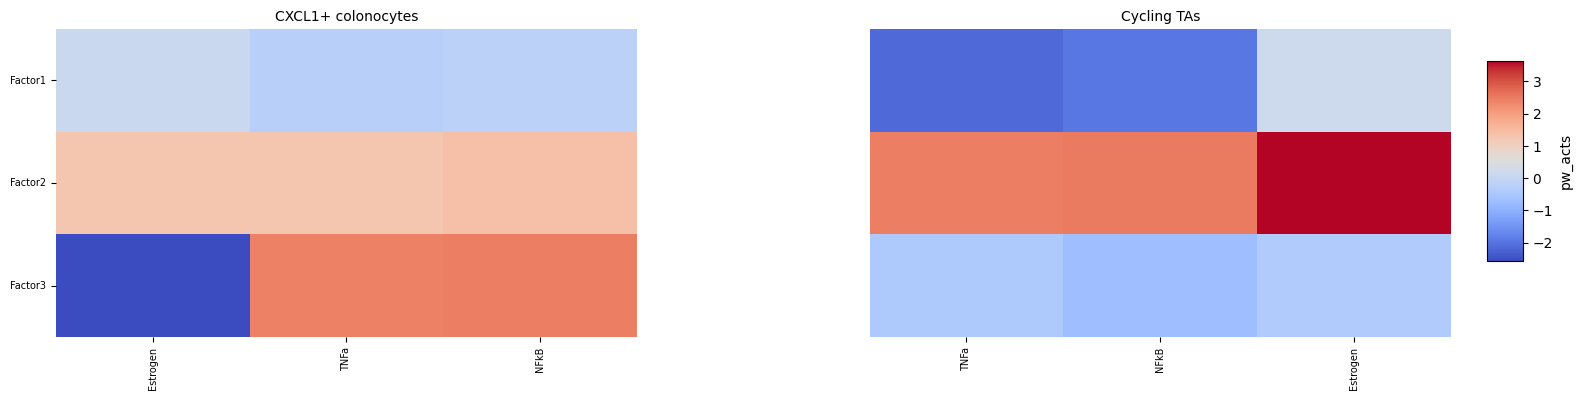

In [19]:
# Now you can run decoupler for each matrix of gene loadings
progeny = dc.op.progeny(organism="human", top=1000)
mcp_pws = mina.down.run_ulm_per_view(view_dict=feature_loadings, net=progeny)
mina.pl.plot_mcell_funcomics(mcp_pws, 
                     p_threshold=0.05,
                     top_n=15,
                     use_var=True,
                     figsize=(18, 4))

In [20]:
amodel = mina.down.model_to_anndata(
    anndata_dict=anndata_dict,
    metadata=metadata,
    model=model,
)

In [21]:
scores = mina.down.factor_scores_info(
    amodel,
    obs_keys=["disease__ontology_label", "organ"],
)

In [22]:
variance_df = mina.down.variance_by_view_info(amodel)
variance_df.head()

,Factor,View,Variance
0,Factor1,BEST4+ colonocytes,0.196241
1,Factor1,CXCL1+ colonocytes,0.158587
2,Factor1,Colonocytes,0.237706
3,Factor1,Cycling TAs,0.161681
4,Factor1,Enterocytes,0.152827


In [23]:
variance_detail = mina.down.variance_by_view_info(
    amodel,
    aggregate_groups=False,
)
variance_detail.head()

,Factor,View,Group,View_group,Variance
0,Factor1,BEST4+ colonocytes,group_1,BEST4+ colonocytes:group_1,0.196241
1,Factor2,BEST4+ colonocytes,group_1,BEST4+ colonocytes:group_1,0.108082
2,Factor3,BEST4+ colonocytes,group_1,BEST4+ colonocytes:group_1,0.132411
3,Factor1,CXCL1+ colonocytes,group_1,CXCL1+ colonocytes:group_1,0.158587
4,Factor2,CXCL1+ colonocytes,group_1,CXCL1+ colonocytes:group_1,0.123559


In [24]:
reconstruction = mina.down.reconstruction_info(amodel)
reconstruction_df = reconstruction["by_view"]
reconstruction_df.head()

,view,R,R2
0,BEST4+ colonocytes,0.682742,0.466136
1,CXCL1+ colonocytes,0.660893,0.436780
2,Colonocytes,0.709948,0.504026
3,Cycling TAs,0.693996,0.481631
4,Enterocytes,0.668216,0.446513


In [25]:
featureclass_df = mina.down.featureclass_variance_info(
    amodel,
    feature_type_map={
        "Innate": [
            "DDX58", "IFIH1", "IFNAR1", "IFNGR1", "IFNLR1", "IRF3", "ISG15",
            "RSAD2", "TBK1", "TMEM173", "TLR3", "TLR4", "MYD88", "TICAM1",
            "RELA", "CXCL10", "IFIT1",
        ],
        "Cytokine": [
            "IL1B", "IL1R1", "IL6R", "IL6ST", "IL17RA", "IL17RC", "IL18",
            "IL22RA1", "IL33", "IL4R", "IL13RA1", "TNFRSF1A", "TNFRSF1B",
            "OSMR", "LIF", "CXCL1", "CXCL6", "CXCL8", "CCL15", "CCL20",
            "C3", "CASP1", "CASP4", "PYCARD",
        ],
        "Proliferation": [
            "MKI67", "PCNA", "PCLAF", "TOP2A", "TYMS", "TK1", "BIRC5",
            "CCNB1", "CDCA7", "DUT", "RRM2", "STMN1", "TUBA1A", "TUBB",
            "TUBB3", "BRCA2",
        ],
    },
)
featureclass_df.head()

,Factor,Feature_type,Variance
0,Factor1,Innate,0.133916
1,Factor2,Innate,0.121465
2,Factor3,Innate,0.067558
3,Factor1,Cytokine,0.177025
4,Factor2,Cytokine,0.209047


In [26]:
loadings = mina.down.variable_loadings_info(amodel)

top_spatial = mina.down.top_features_by_view_info(
    loadings,
    factors=["Factor1"],
    top_per_view=10,
)

top_by_class = mina.down.top_features_by_class_info(
    loadings,
    feature_types={
        "CD3D": "immune",
        "CXCL8": "immune",
        "EPCAM": "epithelial",
    },
    factors=["Factor1", "Factor2"],
    top_per_class=5,
)
top_by_class

,variable,view,feature_type,weight,factor
0,IFNGR1,BEST4+ colonocytes,NA,1.705611,Factor1
1,CHP2,Tuft cells,NA,-1.590235,Factor1
2,RANBP1,Immature goblet cells,NA,1.577188,Factor2
3,RANBP1,Tuft cells,NA,1.571198,Factor2
4,HIF1A,Tuft cells,NA,1.527154,Factor1
5,CXCL8,Enteroendocrine cells,immune,0.781919,Factor1


In [27]:
kruskal_df = mina.down.kruskal_info(
    scores,
    group_col="disease__ontology_label",
)
kruskal_df.head()

,factor,pvalue
0,Factor1,0.210897
1,Factor2,0.440738
2,Factor3,0.705178


In [28]:
scores["ordinal_disease"] = scores.disease__ontology_label.astype("category").cat.codes
kendall_df = mina.down.kendall_info(
    scores,
    ordinal_col="ordinal_disease",
)
kendall_df.head()

,factor,tau,pvalue
0,Factor1,0.499163,0.058415
1,Factor3,0.294960,0.502220
2,Factor2,-0.022689,1.000000


In [29]:
ellipse_df = mina.down.confidence_ellipses_info(
    scores,
    x_factor="Factor1",
    y_factor="Factor2",
    group_col="disease__ontology_label",
)

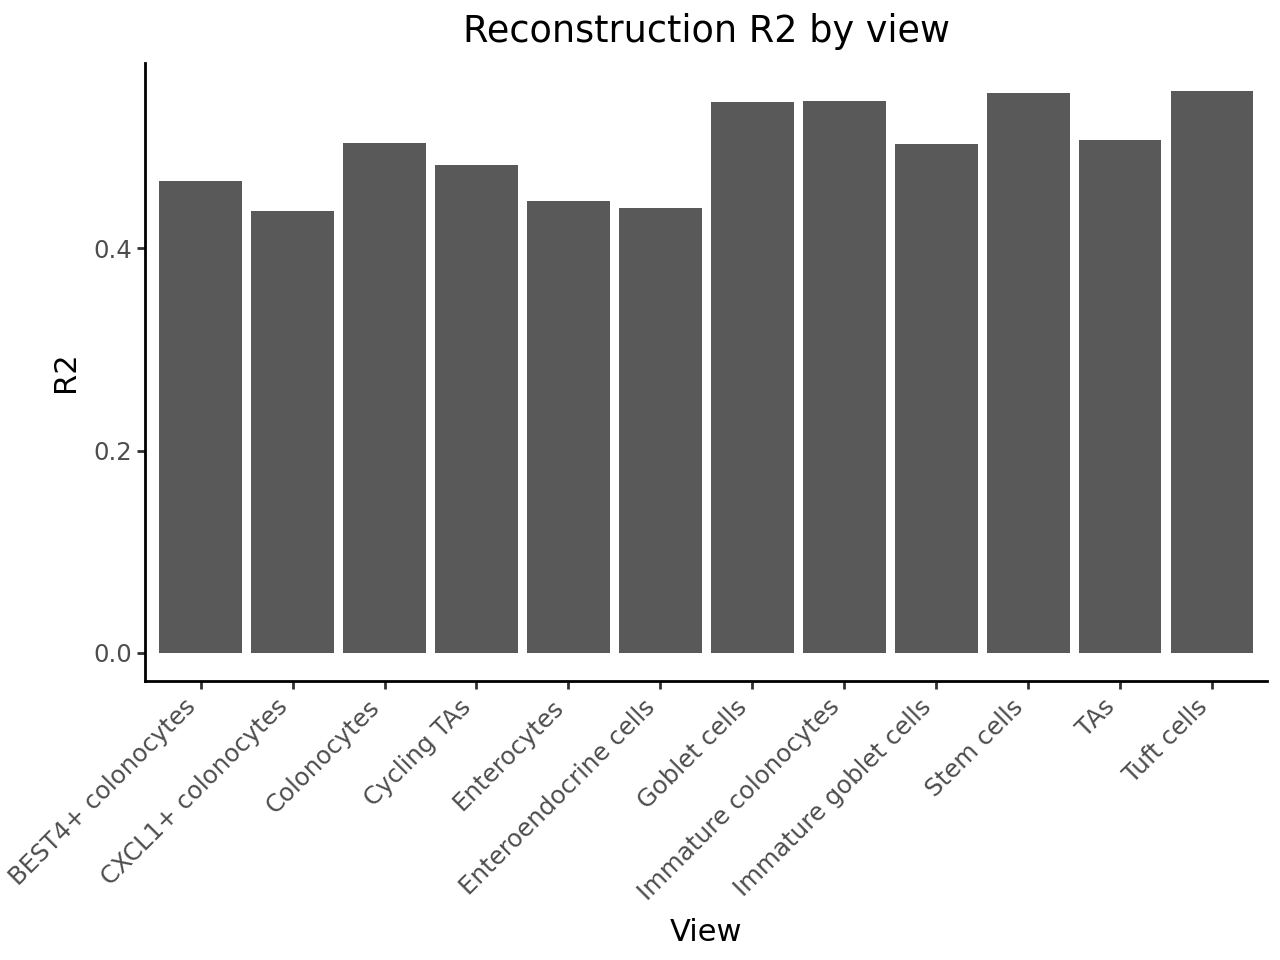

In [30]:
mina.pl.plot_reconstruction(reconstruction_df)


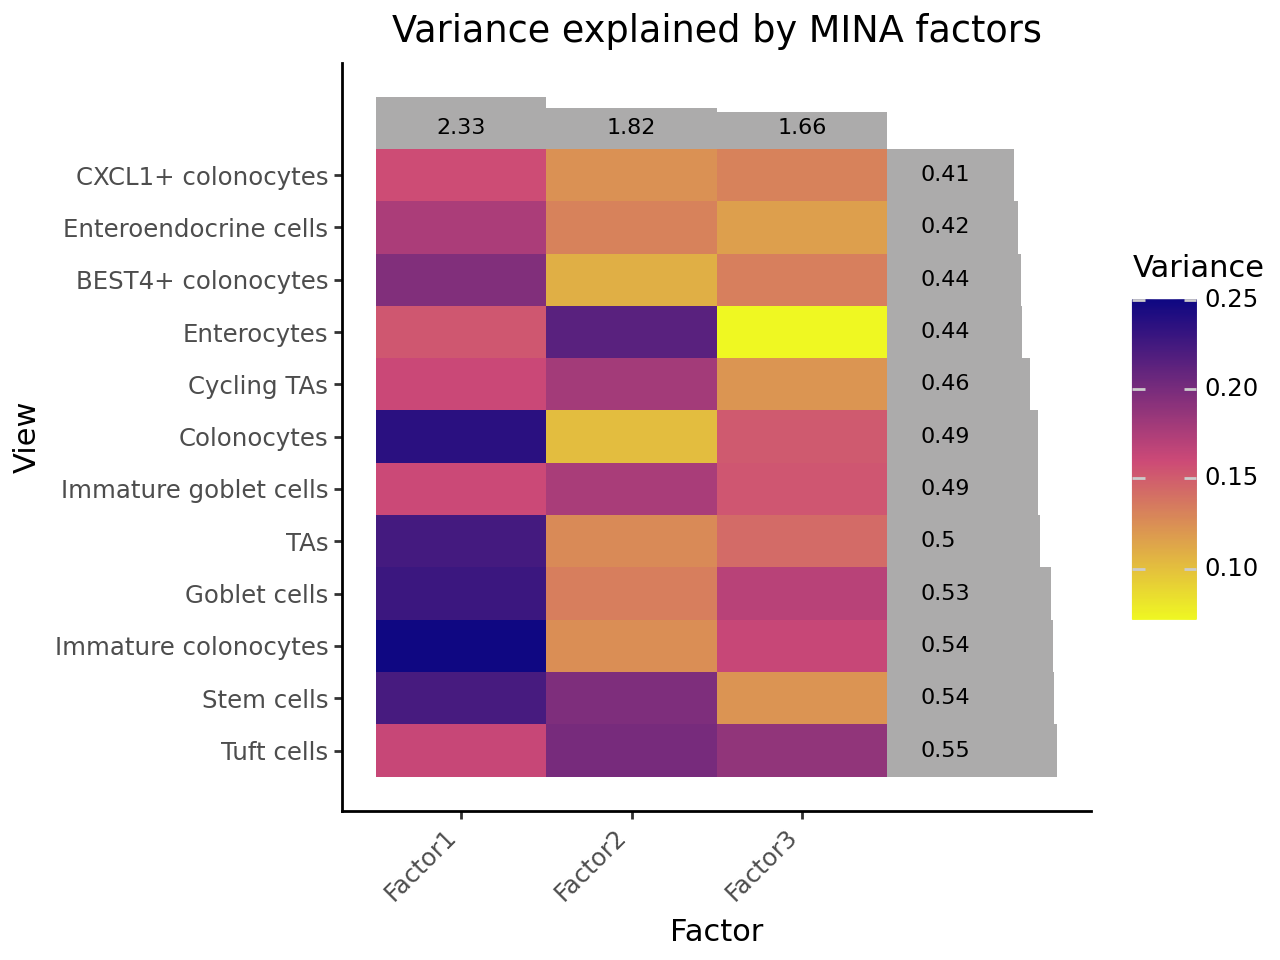

In [31]:
mina.pl.plot_variance_by_view(variance_df)

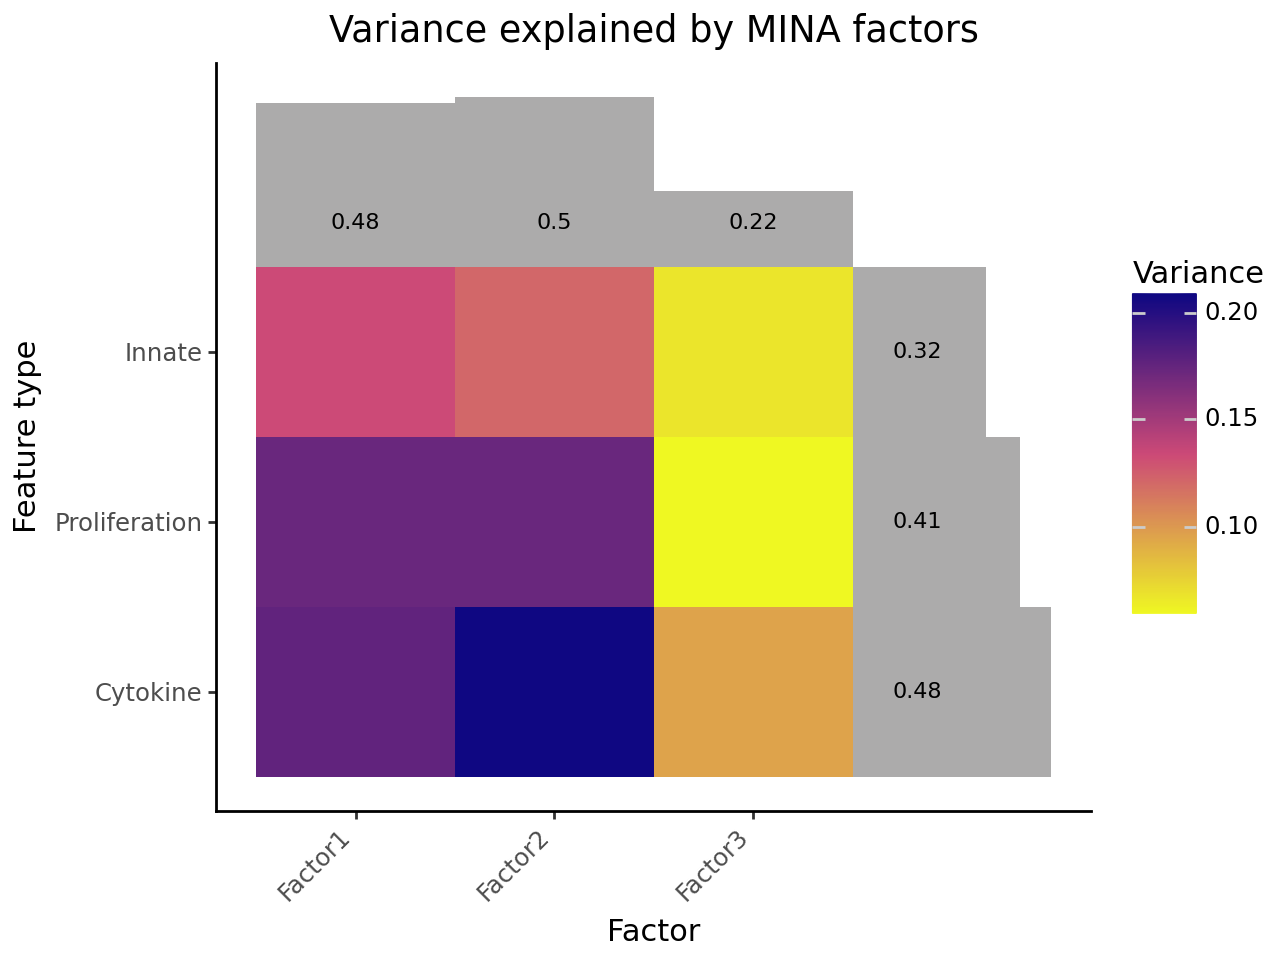

In [32]:
mina.pl.plot_featureclass_variance(featureclass_df)

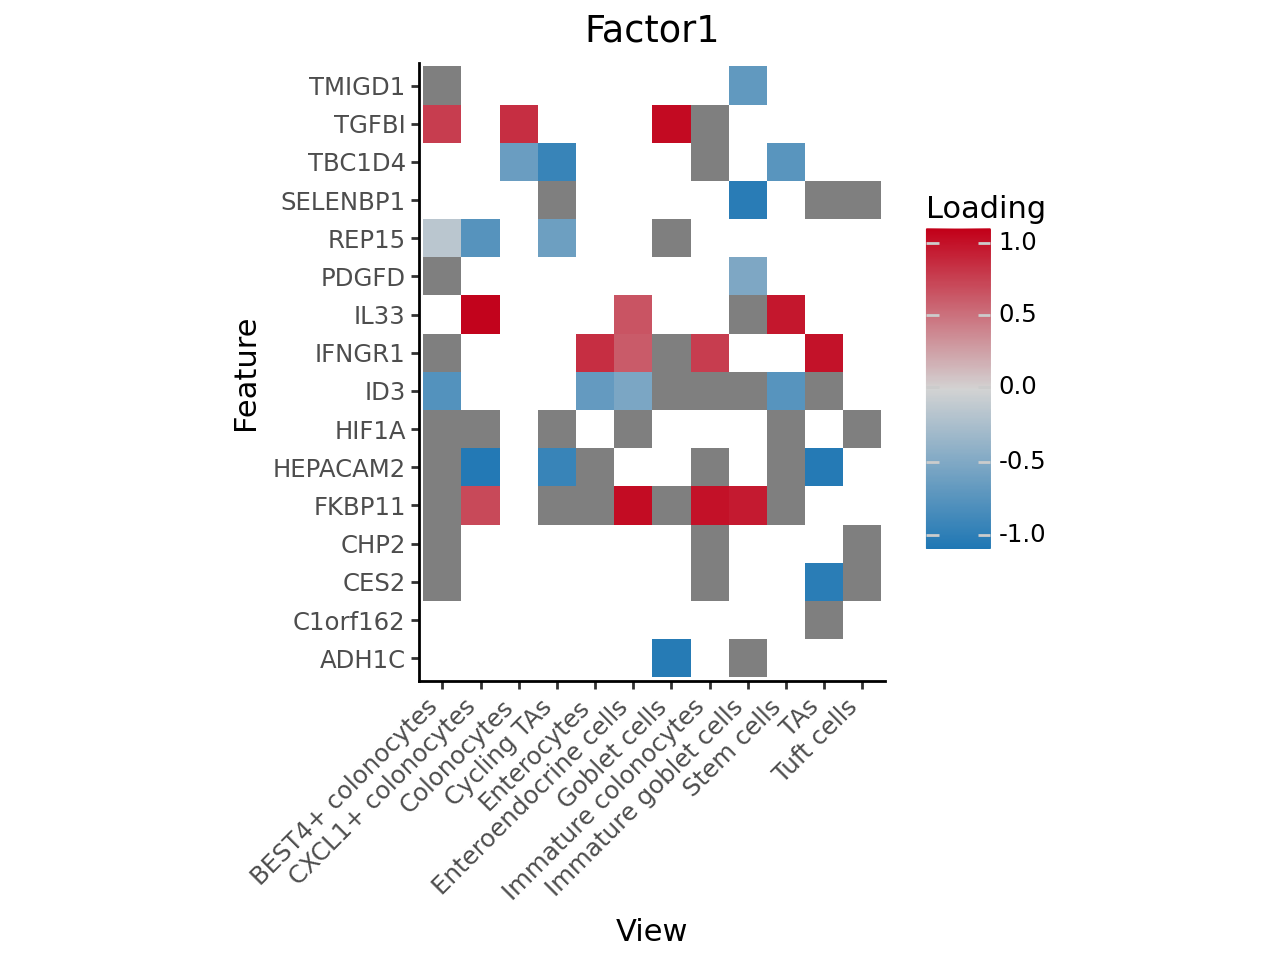

In [33]:
mina.pl.plot_top_loadings_heatmap(
    loadings,
    factor="Factor1",
    top_n=25,
)

/home/loan/Documents/Tests/MINA/.venv/lib/python3.13/site-packages/plotnine/layer.py:293: PlotnineWarning: stat_ydensity : Removed 1 rows containing non-finite values.
/home/loan/Documents/Tests/MINA/.venv/lib/python3.13/site-packages/plotnine/positions/position.py:232: PlotnineWarning: position_dodge requires non-overlapping x intervals


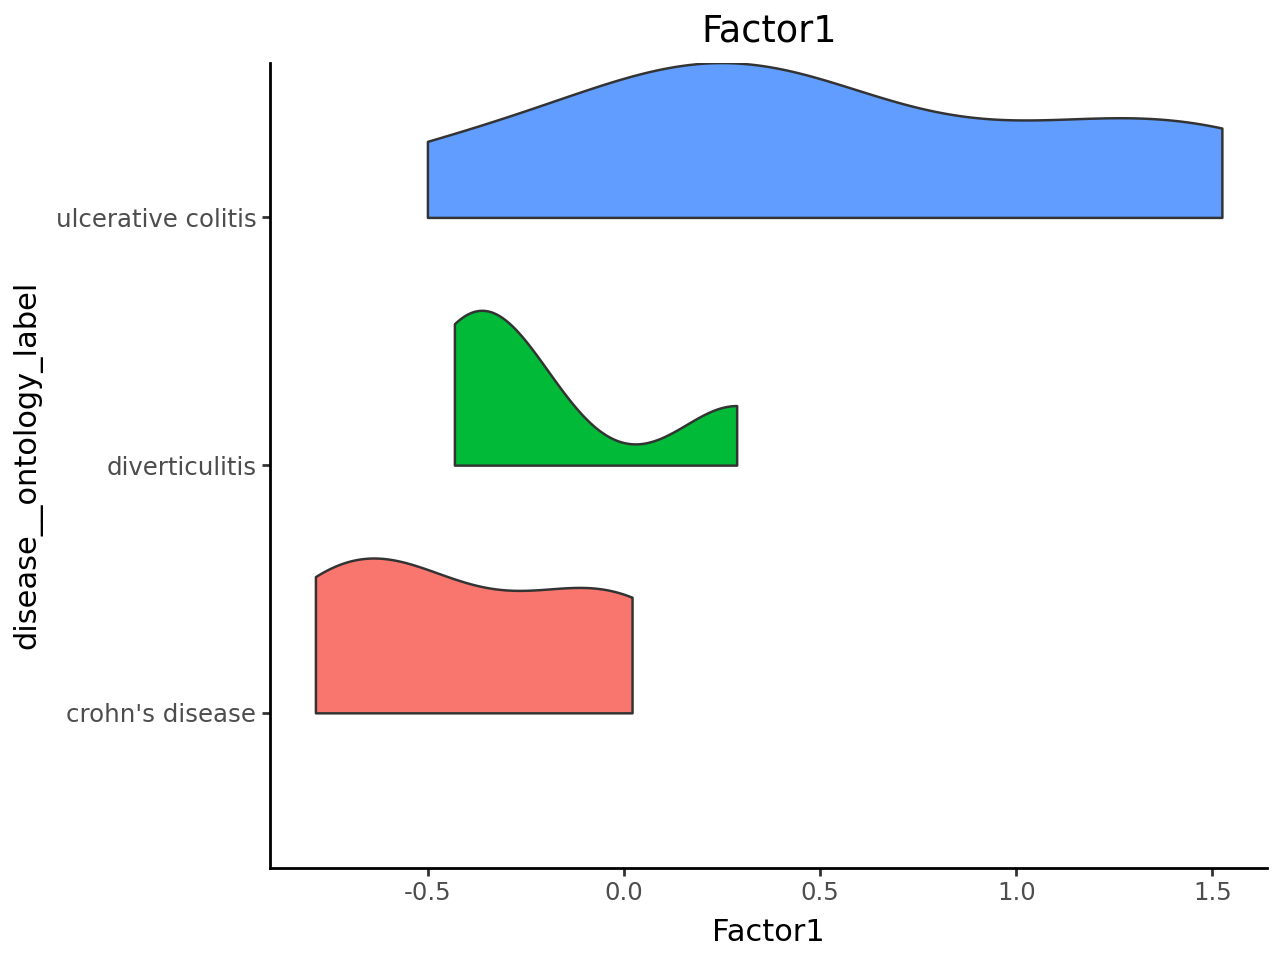

In [34]:
mina.pl.plot_factor_violin(
    scores,
    factor="Factor1",
    group_col="disease__ontology_label",
)


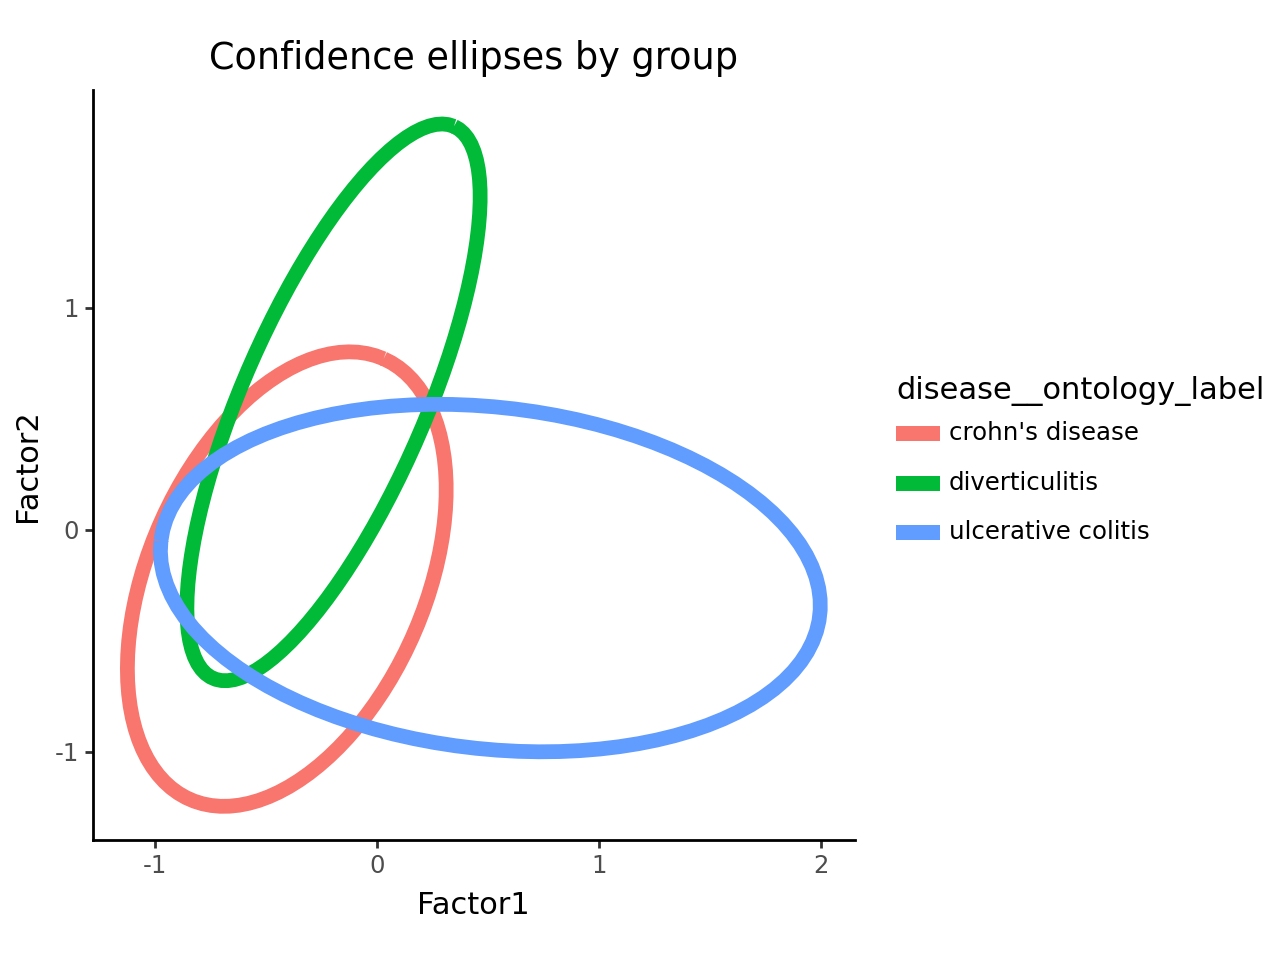

In [35]:
mina.pl.plot_confidence_ellipses(
    scores,
    ellipse_df,
    x_factor="Factor1",
    y_factor="Factor2",
    group_col="disease__ontology_label",
)

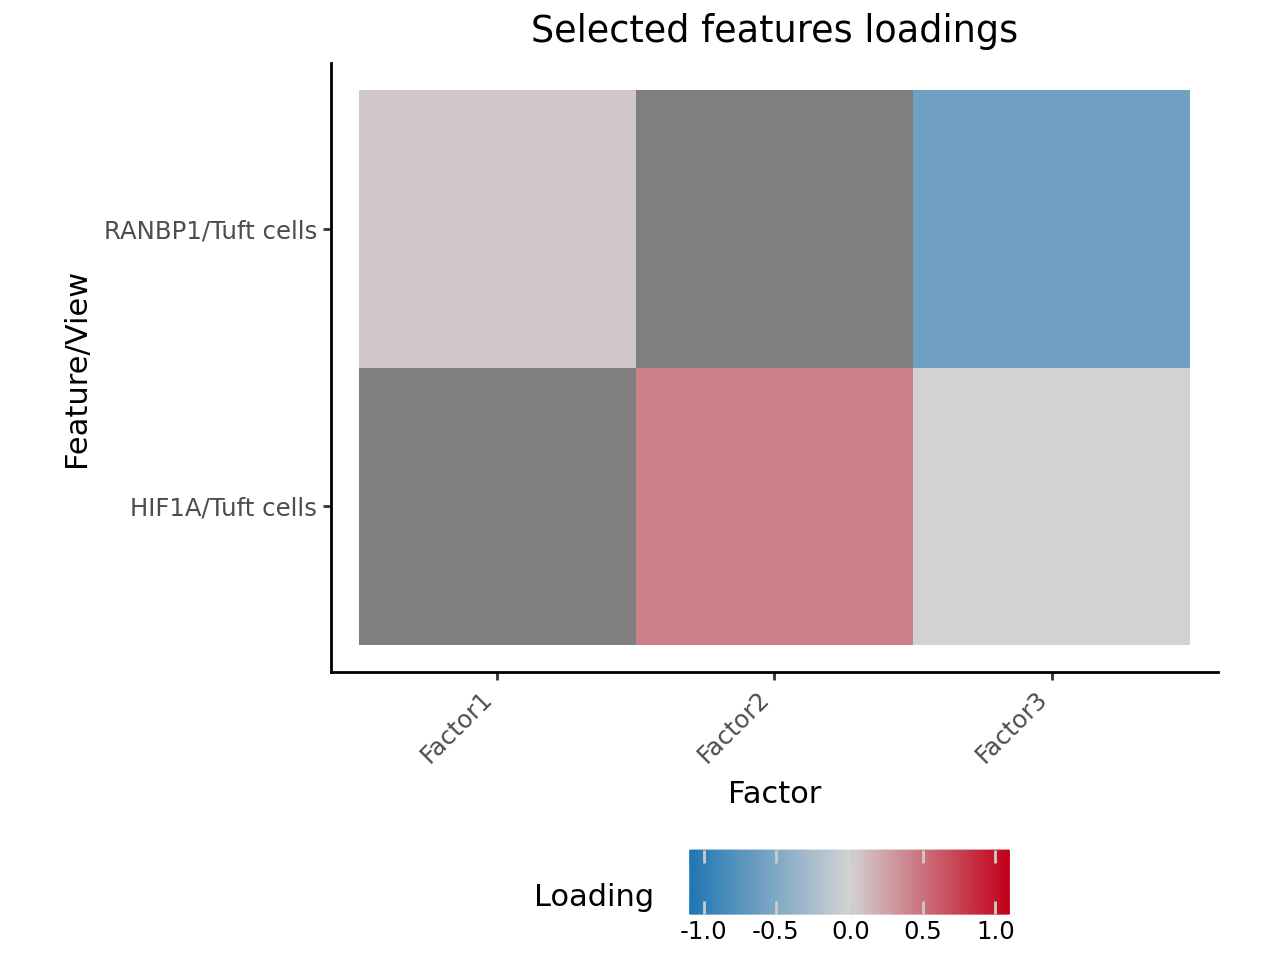

In [36]:
ft_to_display = ["FKBP11", "RANBP1", "HIF1A"]
selected_df = mina.down.selected_features_info(
    loadings,
    selections=[(ft, 'Tuft cells') for ft in ft_to_display],
)
mina.pl.plot_selected_features(
    selected_df,
)